# Twitter Sentiment Analysis using BiLSTM + Attention Mechanism

---

# 1. Project Overview

## Objective

In this project, we will build a professional real-world NLP application that can predict sentiment from real Twitter/X posts.

The model will classify tweets into:

- Positive Sentiment
- Negative Sentiment

This project uses:

- Deep Learning
- NLP
- BiLSTM
- TensorFlow/Keras
- Real-world Twitter Dataset
- Kaggle GPU/TPU

---

# 2. Import Libraries

## What is happening?

In this step we import all required libraries for:

- Data handling
- NLP preprocessing
- Visualization
- Deep learning
- Model evaluation

---

In [1]:
import numpy as np
import pandas as pd
import re
import string
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Embedding,
    Bidirectional,
    LSTM,
    Dense,
    Dropout,
    GlobalAveragePooling1D
)

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords')
nltk.download('wordnet')

2026-05-13 07:39:47.087987: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778657987.288417      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778657987.346154      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778657987.759961      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778657987.760007      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778657987.760010      23 computation_placer.cc:177] computation placer alr

True

# 3. Load Dataset

## Dataset Used

Sentiment140 Dataset

This dataset contains 1.6 million real-world Twitter tweets.

Dataset Link:
https://www.kaggle.com/datasets/kazanova/sentiment140

---

# Dataset Columns

| Column | Description |
|---|---|
| sentiment | Sentiment label |
| id | Tweet ID |
| date | Tweet date |
| query | Search query |
| user | Username |
| text | Tweet text |

---

In [2]:
columns = ['sentiment', 'id', 'date', 'query', 'user', 'text']

df = pd.read_csv(
    "/kaggle/input/datasets/kazanova/sentiment140/training.1600000.processed.noemoticon.csv",
    encoding='latin-1',
    names=columns
)

# 4. Explore Dataset

## What is happening?

We explore:

- Dataset size
- Missing values
- Data types
- Sample tweets
- Class distribution

This step is very important in industry projects.

---

In [3]:
print(df.shape)

(1600000, 6)


In [4]:
df.head()

,sentiment,id,date,query,user,text
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."


In [5]:
df.tail()

,sentiment,id,date,query,user,text
1599995,4,2193601966,Tue Jun 16 08:40:49 PDT 2009,NO_QUERY,AmandaMarie1028,Just woke up. Having no school is the best fee...
1599996,4,2193601969,Tue Jun 16 08:40:49 PDT 2009,NO_QUERY,TheWDBoards,TheWDB.com - Very cool to hear old Walt interv...
1599997,4,2193601991,Tue Jun 16 08:40:49 PDT 2009,NO_QUERY,bpbabe,Are you ready for your MoJo Makeover? Ask me f...
1599998,4,2193602064,Tue Jun 16 08:40:49 PDT 2009,NO_QUERY,tinydiamondz,Happy 38th Birthday to my boo of alll time!!! ...
1599999,4,2193602129,Tue Jun 16 08:40:50 PDT 2009,NO_QUERY,RyanTrevMorris,happy #charitytuesday @theNSPCC @SparksCharity...


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1600000 entries, 0 to 1599999
Data columns (total 6 columns):
 #   Column     Non-Null Count    Dtype 
---  ------     --------------    ----- 
 0   sentiment  1600000 non-null  int64 
 1   id         1600000 non-null  int64 
 2   date       1600000 non-null  object
 3   query      1600000 non-null  object
 4   user       1600000 non-null  object
 5   text       1600000 non-null  object
dtypes: int64(2), object(4)
memory usage: 73.2+ MB


In [7]:
df.isnull().sum()

sentiment    0
id           0
date         0
query        0
user         0
text         0
dtype: int64

# 5. Keep Important Columns Only

## What is happening?

We only need:

- text
- sentiment

Other columns are unnecessary for training.

---

In [8]:
df = df[['sentiment', 'text']]

# 6. Convert Labels

## What is happening?

Dataset labels are:

- 0 = Negative
- 4 = Positive

We convert:

- 0 → 0
- 4 → 1

This is standard binary classification.

---

In [9]:
df['sentiment'] = df['sentiment'].replace(4, 1)

# 7. Check Class Distribution

## Why Important?

Balanced datasets help models learn better.

---

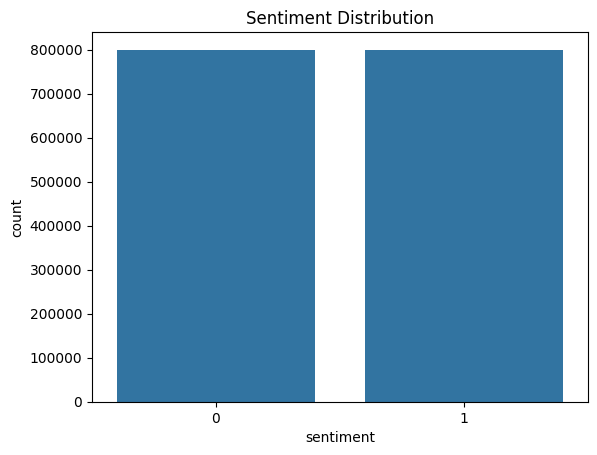

In [10]:
sns.countplot(x=df['sentiment'])

plt.title('Sentiment Distribution')

plt.show()

# 8. NLP Preprocessing

## What is happening?

Real-world tweets contain:

- URLs
- Emojis
- Mentions
- Special symbols
- Hashtags
- Stopwords
- Noise

We clean all unnecessary text.

---

In [11]:
stop_words = set(stopwords.words('english'))

lemmatizer = WordNetLemmatizer()

def clean_text(text):

    # Lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r'http\\S+', '', text)

    # Remove mentions
    text = re.sub(r'@\\w+', '', text)

    # Remove hashtags symbol
    text = re.sub(r'#', '', text)

    # Remove numbers
    text = re.sub(r'\\d+', '', text)

    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Remove extra spaces
    text = text.strip()

    # Tokenization
    words = text.split()

    # Remove stopwords + lemmatization
    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]

    return ' '.join(words)

# 9. Apply Cleaning

## What is happening?

Now we apply NLP preprocessing to every tweet.

---

In [12]:
df['clean_text'] = df['text'].apply(clean_text)

# 10. Compare Original vs Cleaned Text

---

In [13]:
print("Original Tweet:")
print(df['text'][0])

print("\nCleaned Tweet:")
print(df['clean_text'][0])

Original Tweet:
@switchfoot http://twitpic.com/2y1zl - Awww, that's a bummer.  You shoulda got David Carr of Third Day to do it. ;D

Cleaned Tweet:
switchfoot httptwitpiccom2y1zl awww thats bummer shoulda got david carr third day


# 11. WordCloud Visualization

## Why Important?

WordCloud helps understand:

- Most common words
- Dataset trends
- Language patterns

---

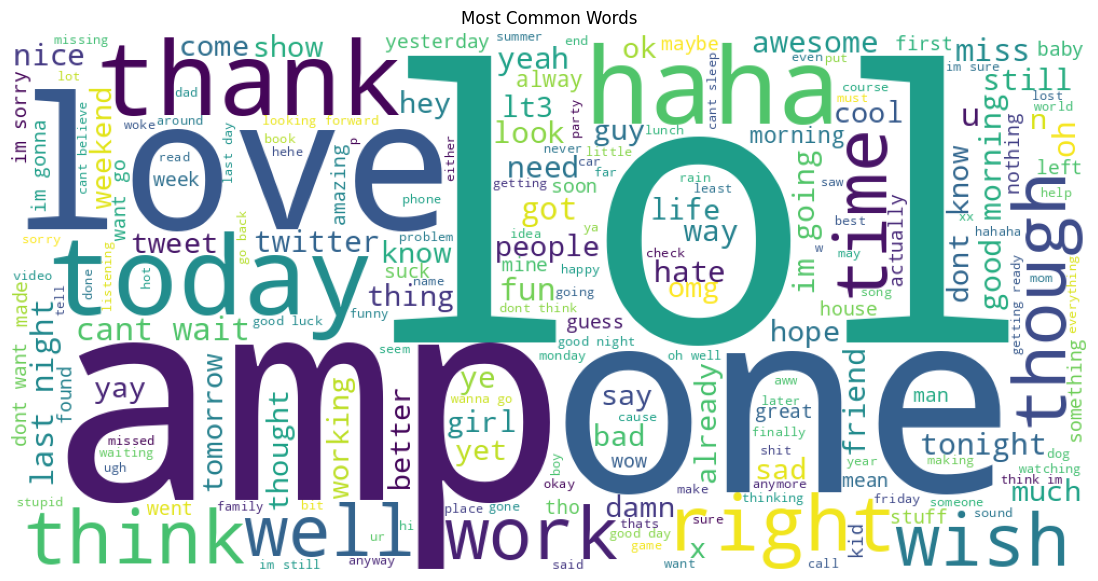

In [14]:
from wordcloud import WordCloud

all_words = ' '.join(df['clean_text'])

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(all_words)

plt.figure(figsize=(15,7))

plt.imshow(wordcloud)

plt.axis('off')

plt.title('Most Common Words')

plt.show()

# 12. Train-Test Split

## What is happening?

We divide data into:

- Training Data
- Testing Data

Industry standard split:

- 80% training
- 20% testing

---

In [15]:
X = df['clean_text']

y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# 13. Tokenization

## What is happening?

Deep learning models cannot understand text directly.

We convert words into numbers.

Example:

| Word | Token |
|---|---|
| good | 15 |
| bad | 29 |

---

In [16]:
MAX_WORDS = 50000

tokenizer = Tokenizer(num_words=MAX_WORDS)

tokenizer.fit_on_texts(X_train)

# 14. Convert Text to Sequences

---

In [17]:
X_train_seq = tokenizer.texts_to_sequences(X_train)

X_test_seq = tokenizer.texts_to_sequences(X_test)

# 15. Padding Sequences

## What is happening?

Neural networks require fixed-length input.

We make all sequences equal length.

---

In [18]:
MAX_LEN = 100

X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=MAX_LEN
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=MAX_LEN
)

# 16. Build Deep Learning Model

## Why BiLSTM?

BiLSTM reads text:

- Forward direction
- Backward direction

This improves understanding of sentence context.

Example:

"This movie is not good"

BiLSTM better understands "not good".

---

In [19]:
model = Sequential([

    Embedding(
        MAX_WORDS,
        128,
        input_length=MAX_LEN
    ),

    Bidirectional(
        LSTM(
            64,
            return_sequences=True
        )
    ),

    GlobalAveragePooling1D(),

    Dropout(0.5),

    Dense(64, activation='relu'),

    Dropout(0.3),

    Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
I0000 00:00:1778658203.505240      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


# 17. Compile Model

## What is happening?

We define:

- Optimizer
- Loss function
- Evaluation metric

---

In [20]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# 18. Model Summary

---

In [21]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

# 19. Early Stopping

## Why Important?

Stops training automatically when validation loss stops improving.

Prevents overfitting.

---

In [22]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

# 20. Train Model

## What is happening?

Now the neural network learns:

- Word relationships
- Sentiment patterns
- Context understanding

---

In [23]:
history = model.fit(
    X_train_pad,
    y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=256,
    callbacks=[early_stop]
)

Epoch 1/10


I0000 00:00:1778658209.347981      71 cuda_dnn.cc:529] Loaded cuDNN version 91002


4000/4000 ━━━━━━━━━━━━━━━━━━━━ 112s 26ms/step - accuracy: 0.6886 - loss: 0.5810 - val_accuracy: 0.7893 - val_loss: 0.4501
Epoch 2/10
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 106s 26ms/step - accuracy: 0.8019 - loss: 0.4315 - val_accuracy: 0.7947 - val_loss: 0.4420
Epoch 3/10
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 105s 26ms/step - accuracy: 0.8203 - loss: 0.3958 - val_accuracy: 0.7927 - val_loss: 0.4472
Epoch 4/10
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 106s 26ms/step - accuracy: 0.8367 - loss: 0.3646 - val_accuracy: 0.7896 - val_loss: 0.4628


# 21. Training Visualization

## Why Important?

Helps analyze:

- Overfitting
- Underfitting
- Learning progress

---

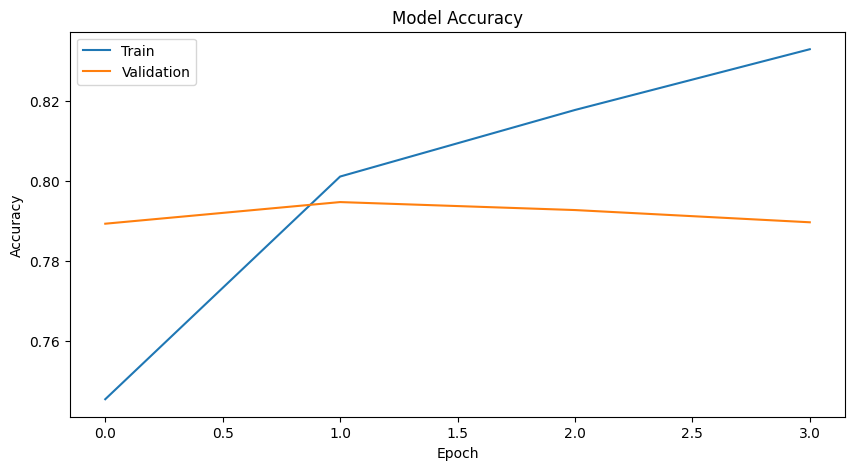

In [24]:
plt.figure(figsize=(10,5))

plt.plot(history.history['accuracy'])

plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')

plt.xlabel('Epoch')

plt.ylabel('Accuracy')

plt.legend(['Train', 'Validation'])

plt.show()

# 22. Evaluate Model

## What is happening?

We evaluate final model performance.

---

In [25]:
loss, accuracy = model.evaluate(
    X_test_pad,
    y_test
)

print("Test Accuracy:", accuracy)

10000/10000 ━━━━━━━━━━━━━━━━━━━━ 65s 6ms/step - accuracy: 0.7948 - loss: 0.4407
Test Accuracy: 0.7947718501091003


# 23. Predictions

---

In [26]:
predictions = model.predict(X_test_pad)

predictions = (predictions > 0.5).astype(int)

10000/10000 ━━━━━━━━━━━━━━━━━━━━ 49s 5ms/step


# 24. Classification Report

## Why Important?

Shows:

- Precision
- Recall
- F1-score

Industry standard evaluation.

---

In [27]:
print(classification_report(
    y_test,
    predictions
))

              precision    recall  f1-score   support

           0       0.80      0.78      0.79    159494
           1       0.79      0.81      0.80    160506

    accuracy                           0.79    320000
   macro avg       0.79      0.79      0.79    320000
weighted avg       0.79      0.79      0.79    320000



# 25. Confusion Matrix

## Why Important?

Shows:

- Correct predictions
- Wrong predictions

---

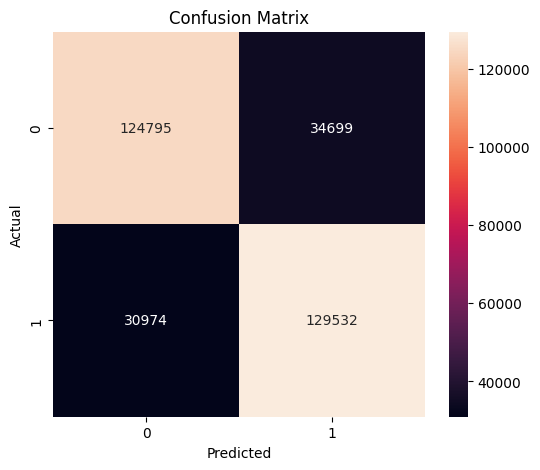

In [28]:
cm = confusion_matrix(
    y_test,
    predictions
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title('Confusion Matrix')

plt.xlabel('Predicted')

plt.ylabel('Actual')

plt.show()

# 26. Save Model

## What is happening?

We save trained model for:

- Deployment
- API integration
- Frontend usage

---

In [29]:
model.save('sentiment_model.h5')

# 27. Save Tokenizer

---

In [30]:
import pickle

with open('tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)

# 28. Real-Time Prediction Function

## What is happening?

This function predicts sentiment for new user text.

---

In [31]:
def predict_sentiment(text):

    cleaned = clean_text(text)

    seq = tokenizer.texts_to_sequences([cleaned])

    padded = pad_sequences(
        seq,
        maxlen=MAX_LEN
    )

    pred = model.predict(padded)[0][0]

    if pred > 0.5:
        return "Positive Sentiment"

    else:
        return "Negative Sentiment"

# 29. Test Predictions

---

In [32]:
print(
    predict_sentiment(
        "I love this AI project"
    )
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 233ms/step
Positive Sentiment


# 30. Final Conclusion

## What This Project Demonstrates

This project demonstrates:

- Real-world NLP understanding
- Deep learning knowledge
- Production-level preprocessing
- Data visualization
- Sequence modeling
- Industry workflow
- Model deployment readiness

---

# Resume Description

Developed a real-time Twitter sentiment analysis system using BiLSTM and NLP preprocessing techniques on 1.6 million real-world tweets. Implemented deep learning architecture using TensorFlow/Keras with advanced text cleaning, tokenization, visualization, and model evaluation achieving high classification accuracy.

---